# Data grouping and gridding for LEO satellite data

GeospaceLAB provides tools for grouping and gridding data from Low Earth Orbit (LEO) satellites. This process is essential for analyzing and visualizing satellite data effectively. For the Swarm mission, the Swarm `Dataset` class has a built-in method (so called `gridding`) for grouping and gridding along-track data. The gridding method allows you to specify the orbit sector to be gridded, the grid resolution, and the type of interpolation/binning to be used. 

The gridding results have been used in a recent study on the polar ionosphere-thermosphere coupling during the May 2024 superstorm  [@cai2026ionosphere], to analyze the spatial distribution of ionospheric electron density, thermospheric neutral density and composition, and their relationship with geomagnetic activity.

:::{note}
The gridding method is designed to work with the Swarm `Dataset` class, which is specifically tailored for handling Swarm satellite data. If you are working with data from other LEO satellites, you may need to implement a custom gridding approach or adapt the existing method to suit your needs.
:::

:::{note}
The gridding method is applicable for along-track data, meaning that the data with support variables like "SC_DATETIME" and "SC_GEO_LAT". Hence, this method is not suitable for several data products, such as Swarm AEJ PBS data, which do not have the necessary support variables for along-track gridding.
:::

In [1]:
import datetime
import matplotlib.pyplot as plt
import numpy as np
import pathlib

import geospacelab.visualization.mpl.dashboards as dashboards

## Simple gridding example

The following function demonstrates an example to call the gridding method for the Swarm DNS POD data product. In this example, we will grid the data in orbit sector of ascending phase with a specified grid resolution and interpolation method.

Create a new figure: Figure(1000x800).
Searching the data product "DNS_POD" with the version "latest" on the server...


The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240510T000000_20240510T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240511T000000_20240511T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240512T000000_20240512T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240513T000000_20240513T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240514T000000_20240514T235930_0301.cdf')] already exists: skip downloading.


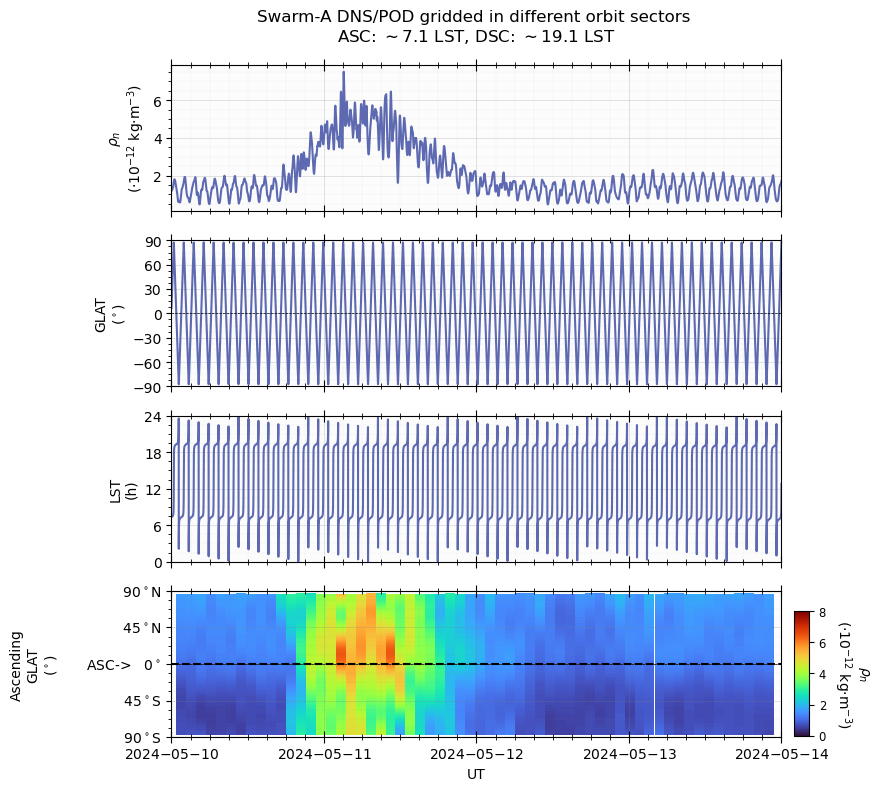

In [7]:
def simple_gridding_example():
    # Initialize the start and end datetime for the data to be gridded
    dt_fr = datetime.datetime(2024, 5, 10, 0, 0, 0)
    dt_to = datetime.datetime(2024, 5, 14, 0, 0, 0)
    sat_id = 'A'
    # Create a Dashboard object for visualizing the gridded data
    db = dashboards.TSDashboard(
        dt_fr = dt_fr,
        dt_to = dt_to,
        figure_config = {
            'figsize': (10, 8),
        }
    )
    ds_pod = db.dock(
        datasource_contents=['esa_eo', 'swarm', 'l2daily', 'dns_pod'], 
        sat_id=sat_id, 
        add_APEX=True, add_AACGM=True,
    )
    
    ds_sector_ASC = ds_pod.gridding(
        # Variable names to be gridded, 
        # which should be a subset of the variables in the original dataset. 
        # The gridded variables will be renamed with a prefix "SECTOR_ASC_GRID_" 
        # to distinguish them from the original variables, 
        # where ASC stands for Ascending.
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        # Sector to be gridded, which can be 'ASC' for ascending phase, 
        # 'DSC' for descending phase, 
        # 'N' for northern hemisphere, 
        # or 'S' for southern hemisphere.
        sector = 'ASC',
        # Coordinate system for the gridding, which can be 'GEO' for geographic coordinates,
        # 'APEX' for apex coordinates, or 'AACGM' for AACGM coordinates.
        sector_cs = 'GEO',
        # Latitude boundary for the sector to be gridded.
        boundary_lat = 90.,
        # Whether to perform along-track interpolation for the gridding.
        along_track_interp=True, 
        # Interpolation method for along-track interpolation, 
        # which can be 'linear' for linear interpolation.
        along_track_interp_method='linear',
        # Grid resolution along the x axis (time axis). 
        # If None, the grid resolution will be automatically determined based on 
        # the satellite orbital period.
        x_grid_res=None,
        # Grid resolution along the y axis (latitude axis) in degrees.
        y_grid_res=0.5,
        # Data resolution for the original data to be gridded. 
        # If None, the data resolution will be automatically determined 
        # based on the original data. For LEO satellite, the resolution is 
        # typically around 90 * 60 = 5400 s.
        x_data_res=None, 
        # Data resolution for the original data. For the POD data, 
        # the resolution is 30 s. 
        y_data_res=30, 
        # Scale factor for the data resolution along the y axis for better visualization.
        y_data_res_scale=1.5,
        visual='on',
    )
    grid_rho_n_ASC = ds_sector_ASC['SECTOR_ASC_GRID_rho_n']
    
    panel_layouts = [
        [ds_pod['rho_n']],
        [ds_pod['SC_GEO_LAT']],
        [ds_pod['SC_GEO_LST']],
        [grid_rho_n_ASC],
    ]
    
    # set axis scale and unit for better visualization, removing exponent for density in the upper-left corner of the panel.
    ds_pod['rho_n'].visual.axis[1].data_scale = 1e12 
    ds_pod['rho_n'].visual.axis[1].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    
    grid_rho_n_ASC.visual.axis[2].data_scale = 1e12
    grid_rho_n_ASC.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    # Set sector labels and data limits for better visualization
    grid_rho_n_ASC.visual.axis[2].lim = [0, 8]
    
    db.set_layout(panel_layouts=panel_layouts, left=0.25, right=0.86, top=0.9, bottom=0.06, hspace=0.2)
    db.draw()
    
    # Post-settings
    # Set panel and axis labels for sector panels
    # For Sector North panel
    ax = db.panels[3]()
    ds_sector_ASC.format_pseudo_lat_axis(ax, 'ASC', inverse=False, add_sperator=True)
    ds_sector_ASC.format_pseudo_lat_label(ax, 'ASC', y_tick_res=45)
    ax.set_ylabel('Ascending\n' + ax.get_ylabel(), labelpad=20)
    
    lsts_asc = ds_sector_ASC.ascending_nodes['GEO_LST']
    lsts_dsc = ds_sector_ASC.descending_nodes['GEO_LST']
    lst_median_asc = lsts_asc[len(lsts_asc) // 2]
    lst_median_dsc = lsts_dsc[len(lsts_dsc) // 2]
    
    db.add_title(
        y=1.03,
        title='Swarm-{} DNS/POD gridded in different orbit sectors \n'.format(ds_pod.sat_id) + \
            r'ASC: $\sim${:.1f} LST, DSC: $\sim${:.1f} LST'.format(lst_median_asc, lst_median_dsc),
        fontsize='large', append_time=False)
    db.show()
    
simple_gridding_example() 

## Gridding data in multiple orbit sectors

The following function demonstrates an example to call the gridding method for the Swarm DNS POD data product in multiple orbit sectors, including
- N: Northern hemisphere,
- S: Southern hemisphere,
- ASC: ascending phase,
- DSC: descending phase. 
  
In this example, we will grid the data in the four sectors with the same grid resolution and interpolation method, and then visualize the gridded results together for comparison.

Create a new figure: Figure(1000x1000).
Searching the data product "DNS_POD" with the version "latest" on the server...


The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240510T000000_20240510T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240511T000000_20240511T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240512T000000_20240512T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240513T000000_20240513T235930_0301.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/DNS_POD/0301/Sat_A/2024/SW_OPER_DNSAPOD_2__20240514T000000_20240514T235930_0301.cdf')] already exists: skip downloading.


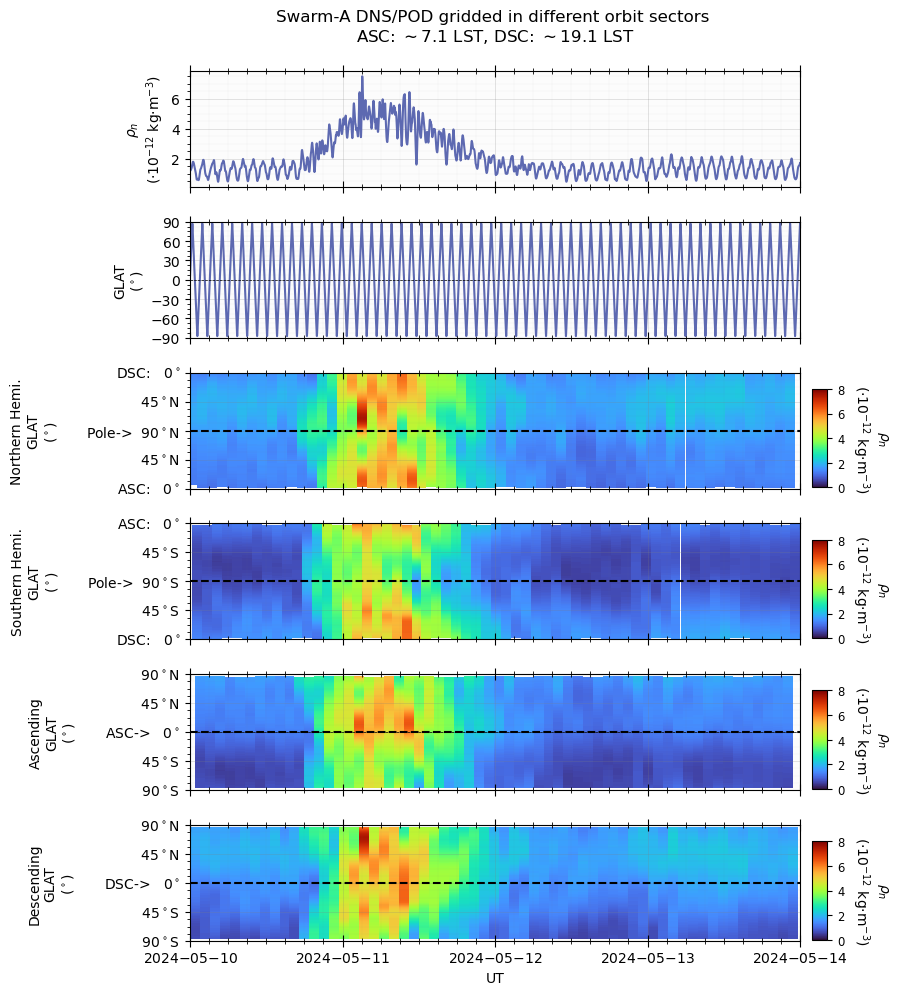

In [4]:

def test_gridding_interpolation_DNS_POD():
    """Test Swarm DNS/POD data product
    
    """
    dt_fr = datetime.datetime(2024, 5, 10, 0, 0)
    dt_to = datetime.datetime(2024, 5, 14, 0, 0)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (10, 10)},
        )

    ds = db.dock(datasource_contents=['esa_eo', 'swarm', 'l2daily', 'dns_pod'], sat_id='A', add_APEX=True, add_AACGM=True)
    
    ds_sector_N = ds.gridding(
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        sector = 'N',
        sector_cs = 'GEO',
        boundary_lat = 0.,
        along_track_interp=True, along_track_interp_method='linear',
        x_grid_res=None,
        y_grid_res=0.5,
        x_data_res=None, 
        y_data_res=30, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    ds_sector_S = ds.gridding(
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        sector = 'S',
        sector_cs = 'GEO',
        boundary_lat = 0.,
        along_track_interp=True, along_track_interp_method='linear',
        x_grid_res=None,
        y_grid_res=0.5,
        x_data_res=None, 
        y_data_res=30, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    ds_sector_ASC = ds.gridding(
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        sector = 'ASC',
        sector_cs = 'GEO',
        boundary_lat = 90.,
        along_track_interp=True, along_track_interp_method='linear',
        x_grid_res=None,
        y_grid_res=0.5,
        x_data_res=None, 
        y_data_res=30, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    ds_sector_DSC = ds.gridding(
        var_names_gridding=['rho_n', 'SC_GEO_ALT', 'SC_GEO_LAT', 'SC_GEO_LON'],
        sector = 'DSC',
        sector_cs = 'GEO',
        boundary_lat = 90.,
        along_track_interp=True, along_track_interp_method='linear',
        x_grid_res=None,
        y_grid_res=0.5,
        x_data_res=None, 
        y_data_res=30, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    grid_rho_n_N = ds_sector_N['SECTOR_N_GRID_rho_n']
    grid_rho_n_S = ds_sector_S['SECTOR_S_GRID_rho_n']
    grid_rho_n_ASC = ds_sector_ASC['SECTOR_ASC_GRID_rho_n']
    grid_rho_n_DSC = ds_sector_DSC['SECTOR_DSC_GRID_rho_n']
    
    panel_layouts = [
        [ds['rho_n']],
        [ds['SC_GEO_LAT']],
        # [ds['SC_GEO_LON']],
        # [ds['SC_GEO_LST']],
        [grid_rho_n_N],
        [grid_rho_n_S],
        [grid_rho_n_ASC],
        [grid_rho_n_DSC],
    ]
    
    # set axis scale and unit for better visualization, removing exponent for density in the upper-left corner of the panel.
    ds['rho_n'].visual.axis[1].data_scale = 1e12 
    ds['rho_n'].visual.axis[1].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    
    grid_rho_n_N.visual.axis[2].data_scale = 1e12
    grid_rho_n_N.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    grid_rho_n_S.visual.axis[2].data_scale = 1e12
    grid_rho_n_S.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    grid_rho_n_ASC.visual.axis[2].data_scale = 1e12
    grid_rho_n_ASC.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    grid_rho_n_DSC.visual.axis[2].data_scale = 1e12
    grid_rho_n_DSC.visual.axis[2].unit = r'$\cdot$10$^{-12}$ kg$\cdot$m$^{-3}$'
    
    # Set sector labels and data limits
    grid_rho_n_N.visual.axis[2].lim = [0, 8]
    grid_rho_n_S.visual.axis[2].lim = [0, 8]
    grid_rho_n_ASC.visual.axis[2].lim = [0, 8]
    grid_rho_n_DSC.visual.axis[2].lim = [0, 8]
    
    db.set_layout(panel_layouts=panel_layouts, left=0.25, right=0.86, top=0.93, bottom=0.06, hspace=0.3)
    db.draw()
    
    # Post-settings
    # Set panel and axis labels for sector panels
    # For Sector North panel
    ax = db.panels[2]()
    ds_sector_N.format_pseudo_lat_axis(ax, 'N', inverse=False, add_sperator=True)
    ds_sector_N.format_pseudo_lat_label(ax, 'N', y_tick_res=45)
    ax.set_ylabel('Northern Hemi.\n' + ax.get_ylabel(), labelpad=20)
    ax = db.panels[3]()
    ds_sector_S.format_pseudo_lat_axis(ax, 'S', inverse=False, add_sperator=True)
    ds_sector_S.format_pseudo_lat_label(ax, 'S', y_tick_res=45)
    ax.set_ylabel('Southern Hemi.\n' + ax.get_ylabel(), labelpad=20)
    ax = db.panels[4]()
    ds_sector_ASC.format_pseudo_lat_axis(ax, 'ASC', inverse=False, add_sperator=True)
    ds_sector_ASC.format_pseudo_lat_label(ax, 'ASC', y_tick_res=45)
    ax.set_ylabel('Ascending\n' + ax.get_ylabel(), labelpad=20)
    ax = db.panels[5]()
    ds_sector_DSC.format_pseudo_lat_axis(ax, 'DSC', inverse=True, add_sperator=True)
    ds_sector_DSC.format_pseudo_lat_label(ax, 'DSC', y_tick_res=45)
    ax.set_ylabel('Descending\n' + ax.get_ylabel(), labelpad=20)
    
    lsts_asc = ds_sector_N.ascending_nodes['GEO_LST']
    lsts_dsc = ds_sector_N.descending_nodes['GEO_LST']
    lst_median_asc = lsts_asc[len(lsts_asc) // 2]
    lst_median_dsc = lsts_dsc[len(lsts_dsc) // 2]
    
    db.add_title(
        y=1.03,
        title='Swarm-{} DNS/POD gridded in different orbit sectors \n'.format(ds.sat_id) + \
            r'ASC: $\sim${:.1f} LST, DSC: $\sim${:.1f} LST'.format(lst_median_asc, lst_median_dsc),
        fontsize='large', append_time=False)
    
    return db
db = test_gridding_interpolation_DNS_POD()
db.show()

## Gridding data by binning instead of interpolation 

Above examples use interpolation for gridding. Interpolation is useful when the data points are sparse or unevenly distributed, as it estimates values between known data points. The gridding method also supports binning the data with high time resolution, however, only large temporal scale structures need to be captured. The following function demonstrates how to use binning for gridding the Swarm FAC (1-s) data in the Northern hemispheric sector, and then visualize the results.

In addition, the gridding method also supports interpolating/binning the data with geomagnetic coordinate system, such as APEX, which is commonly used for ionospheric data analysis. The following function demonstrates how to use the gridding method to interpolate the Swarm FAC data in the Northern hemispheric sector with APEX coordinates, and then visualize the results.

Create a new figure: Figure(1000x1000).
Searching the data product "FAC_TMS" with the version "latest" on the server...
INFO: Indexing the files for the product FAC_TMS of the satellite A ...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240510T000000_20240510T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240511T000000_20240511T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240512T000000_20240512T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level2daily/FAC_TMS/0401/Sat_A/2024/SW_OPER_FACATMS_2F_20240513T000000_20240513T235959_0401.cdf')] already exists: skip downloading.
The file [PosixPath('/data/afys-ionosphere/d

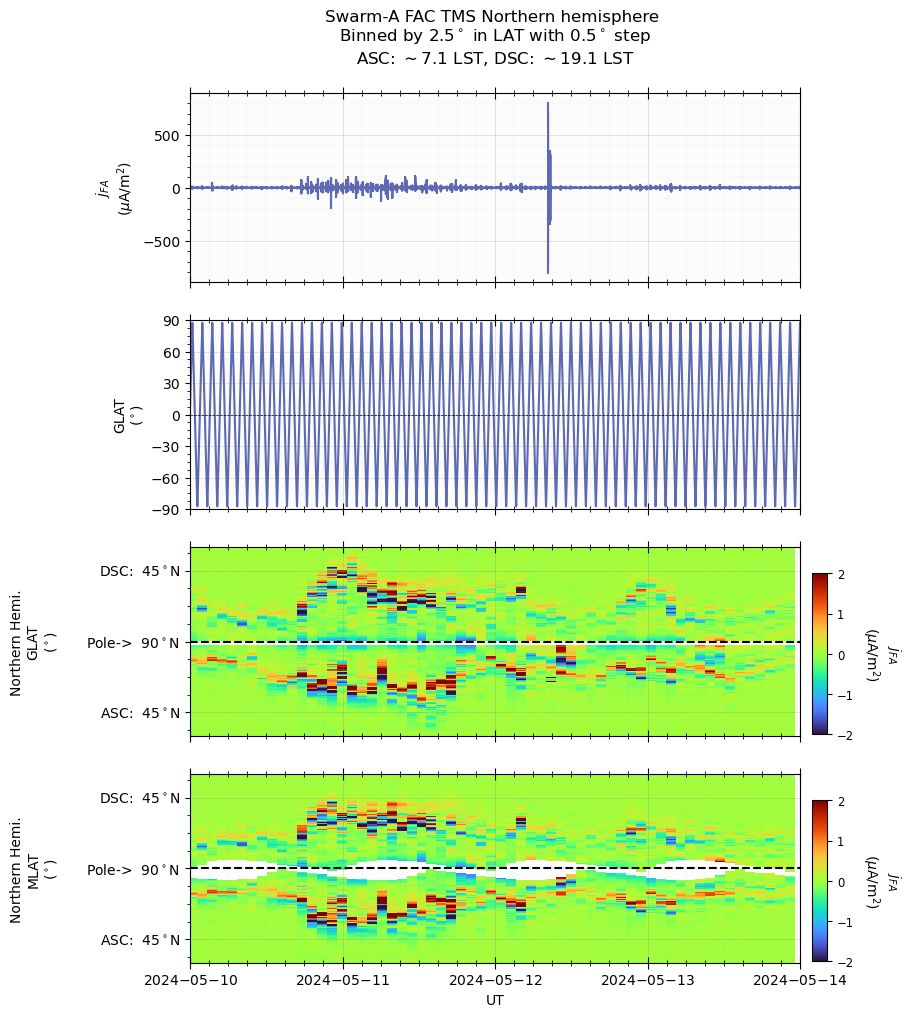

In [5]:

    
def test_gridding_binning_FAC_TMS():
    """Test Swarm FAC TMS data product
    
    """
    dt_fr = datetime.datetime(2024, 5, 10, 0, 0)
    dt_to = datetime.datetime(2024, 5, 14, 0, 0)

    db = dashboards.TSDashboard(
        dt_fr=dt_fr, dt_to=dt_to, figure_config={'figsize': (10, 10)},
    )

    # ds_tms_dual = db.dock(datasource_contents=['esa_eo', 'swarm', 'l2daily', 'fac_tms_dual'], add_APEX=True,)
    
    ds_tms = db.dock(datasource_contents=['esa_eo', 'swarm', 'l2daily', 'fac_tms'], sat_id='A', add_APEX=True,)
   
    # Grid the data in the Northern hemispheric sector 
    # with geographic coordinates, using binning method for gridding.
    ds_sector_N = ds_tms.gridding(
        var_names_gridding=['j_FA',],
        sector = 'N',
        sector_cs = 'GEO',
        boundary_lat = 30.,
        along_track_binning=True, along_track_interp=False,
        along_track_binning_method='mean',
        along_track_binning_step=0.5,
        along_track_binning_res=2.5,
        x_grid_res=None,
        y_grid_res=2,
        x_data_res=None, 
        y_data_res=1, 
        y_data_res_scale=1.5,
        visual='on',
    )
    # Grid the data in the Northern hemispheric sector 
    # with APEX coordinates, using the same binning method for gridding.
    ds_sector_N_APEX = ds_tms.gridding(
        var_names_gridding=['j_FA',],
        sector = 'N',
        sector_cs = 'APEX',
        boundary_lat = 30.,
        along_track_binning=True, along_track_interp=False,
        along_track_binning_method='mean',
        along_track_binning_step=0.5,
        along_track_binning_res=2.5,
        x_grid_res=None,
        y_grid_res=2,
        x_data_res=None, 
        y_data_res=1, 
        y_data_res_scale=1.5,
        visual='on',
    )
    
    j_FA_N = ds_sector_N['SECTOR_N_GRID_j_FA']
    j_FA_N_APEX = ds_sector_N_APEX['SECTOR_N_GRID_j_FA']
    
    panel_layouts = [
        [ds_tms['j_FA']],
        [ds_tms['SC_GEO_LAT']],
        [j_FA_N,],
        [j_FA_N_APEX,],
    ]
    
    j_FA_N.visual.axis[2].lim = [-2, 2]
    j_FA_N_APEX.visual.axis[2].lim = [-2, 2]
    

    db.set_layout(panel_layouts=panel_layouts, left=0.25, right=0.86, top=0.93, bottom=0.06, hspace=0.2)
    db.draw()
    
    ax = db.panels[2]()
    ds_sector_N.format_pseudo_lat_axis(ax, 'N', inverse=False, add_sperator=True)
    ds_sector_N.format_pseudo_lat_label(ax, 'N', y_tick_res=45)
    ax.set_ylabel('Northern Hemi.\n' + ax.get_ylabel(), labelpad=20)
    ax = db.panels[3]()
    ds_sector_N_APEX.format_pseudo_lat_axis(ax, 'N', inverse=False, add_sperator=True)
    ds_sector_N_APEX.format_pseudo_lat_label(ax, 'N', y_tick_res=45)
    ax.set_ylabel('Northern Hemi.\n' + ax.get_ylabel(), labelpad=20)
    
    lsts_asc = ds_sector_N.ascending_nodes['GEO_LST']
    lsts_dsc = ds_sector_N.descending_nodes['GEO_LST']
    lst_median_asc = lsts_asc[len(lsts_asc) // 2]
    lst_median_dsc = lsts_dsc[len(lsts_dsc) // 2]
    
    db.add_title(
        y=1.03,
        title='Swarm-{} FAC TMS Northern hemisphere \n'.format(ds_tms.sat_id) + \
        r'Binned by 2.5$^\circ$ in LAT with 0.5$^\circ$ step' + '\n' + \
        r'ASC: $\sim${:.1f} LST, DSC: $\sim${:.1f} LST'.format(lst_median_asc, lst_median_dsc),
        fontsize='large', append_time=False)
    
    return db
db = test_gridding_binning_FAC_TMS()
db.show()